In [16]:
import os
import json
import gzip
import requests
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import datetime
import calendar


In [18]:
def generate_timestamps(year, month=None, day=None):
    timestamps = []
    if day is not None and month is not None:
        # Specific day: iterate over 24 hours.
        for hour in range(24):
            dt = datetime.datetime(year, month, day, hour)
            timestamps.append(dt)
    elif month is not None:
        # Specific month: iterate over each day and each hour.
        num_days = calendar.monthrange(year, month)[1]
        for d in range(1, num_days+1):
            for hour in range(24):
                dt = datetime.datetime(year, month, d, hour)
                timestamps.append(dt)
    else:
        # Full year: iterate over all months, days, and hours.
        for m in range(1, 13):
            num_days = calendar.monthrange(year, m)[1]
            for d in range(1, num_days+1):
                for hour in range(24):
                    dt = datetime.datetime(year, m, d, hour)
                    timestamps.append(dt)
    return timestamps


In [35]:
year = 2024
month = 1      # set to None for the entire year
day = 1  
timestamps = generate_timestamps(year, month, day)
print(timestamps)


[datetime.datetime(2024, 1, 1, 0, 0), datetime.datetime(2024, 1, 1, 1, 0), datetime.datetime(2024, 1, 1, 2, 0), datetime.datetime(2024, 1, 1, 3, 0), datetime.datetime(2024, 1, 1, 4, 0), datetime.datetime(2024, 1, 1, 5, 0), datetime.datetime(2024, 1, 1, 6, 0), datetime.datetime(2024, 1, 1, 7, 0), datetime.datetime(2024, 1, 1, 8, 0), datetime.datetime(2024, 1, 1, 9, 0), datetime.datetime(2024, 1, 1, 10, 0), datetime.datetime(2024, 1, 1, 11, 0), datetime.datetime(2024, 1, 1, 12, 0), datetime.datetime(2024, 1, 1, 13, 0), datetime.datetime(2024, 1, 1, 14, 0), datetime.datetime(2024, 1, 1, 15, 0), datetime.datetime(2024, 1, 1, 16, 0), datetime.datetime(2024, 1, 1, 17, 0), datetime.datetime(2024, 1, 1, 18, 0), datetime.datetime(2024, 1, 1, 19, 0), datetime.datetime(2024, 1, 1, 20, 0), datetime.datetime(2024, 1, 1, 21, 0), datetime.datetime(2024, 1, 1, 22, 0), datetime.datetime(2024, 1, 1, 23, 0)]


In [31]:
def download_file(dt, base_url='https://data.gharchive.org', data_folder='data'):
    # Ensure the data folder exists
    os.makedirs(data_folder, exist_ok=True)
    
    # Format the filename and create the full file path
    filename = dt.strftime('%Y-%m-%d-%H.json.gz')
    filepath = os.path.join(data_folder, filename)
    url = f"{base_url}/{filename}"
    
    if not os.path.exists(filepath):
        try:
            response = requests.get(url, stream=True)
            if response.status_code == 200:
                with open(filepath, 'wb') as f:
                    for chunk in response.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
                print(f"Downloaded {filename} to {data_folder}")
            else:
                print(f"Failed to download {filename} (HTTP {response.status_code})")
        except Exception as e:
            print(f"Error downloading {filename}: {e}")
    else:
        print(f"{filename} already exists in {data_folder}, skipping download.")
    
    return filepath

In [37]:
repo_contributors = defaultdict(set)

for dt in tqdm(timestamps, desc="Processing files"):
    filename = download_file(dt)
    try:
        with gzip.open(filename, 'rt', encoding='utf-8') as f:
            for line in f:
                try:
                    event = json.loads(line)
                    # Filter for events that include both actor and repo information
                    actor = event.get("actor", {}).get("login")
                    repo = event.get("repo", {}).get("name")
                    if actor and repo:
                        repo_contributors[repo].add(actor)
                except Exception:
                    continue  # Skip any malformed lines
    except Exception as e:
        print(f"Error processing file {filename}: {e}")

Processing files:   4%|▍         | 1/24 [00:00<00:06,  3.50it/s]

Failed to download 2024-01-01-00.json.gz (HTTP 404)
Error processing file data\2024-01-01-00.json.gz: [Errno 2] No such file or directory: 'data\\2024-01-01-00.json.gz'


Processing files:   8%|▊         | 2/24 [00:00<00:06,  3.66it/s]

Failed to download 2024-01-01-01.json.gz (HTTP 404)
Error processing file data\2024-01-01-01.json.gz: [Errno 2] No such file or directory: 'data\\2024-01-01-01.json.gz'


Processing files:  12%|█▎        | 3/24 [00:00<00:05,  3.70it/s]

...

Processing files:  92%|█████████▏| 22/24 [01:24<00:12,  6.20s/it]

Downloaded 2024-01-01-22.json.gz to data


Processing files:  96%|█████████▌| 23/24 [01:30<00:05,  5.88s/it]

Downloaded 2024-01-01-23.json.gz to data


Processing files: 100%|██████████| 24/24 [01:35<00:00,  3.96s/it]


In [33]:
G = nx.Graph()

for repo, contributors in repo_contributors.items():
    contributors = list(contributors)
    if len(contributors) > 1:
        # Create an edge between every pair of developers for this repository.
        for i in range(len(contributors)):
            for j in range(i+1, len(contributors)):
                if G.has_edge(contributors[i], contributors[j]):
                    G[contributors[i]][contributors[j]]['weight'] += 1
                else:
                    G.add_edge(contributors[i], contributors[j], weight=1)

print(f"\nNumber of developers (nodes): {G.number_of_nodes()}")
print(f"Number of collaboration links (edges): {G.number_of_edges()}")



Number of developers (nodes): 14455
Number of collaboration links (edges): 105640


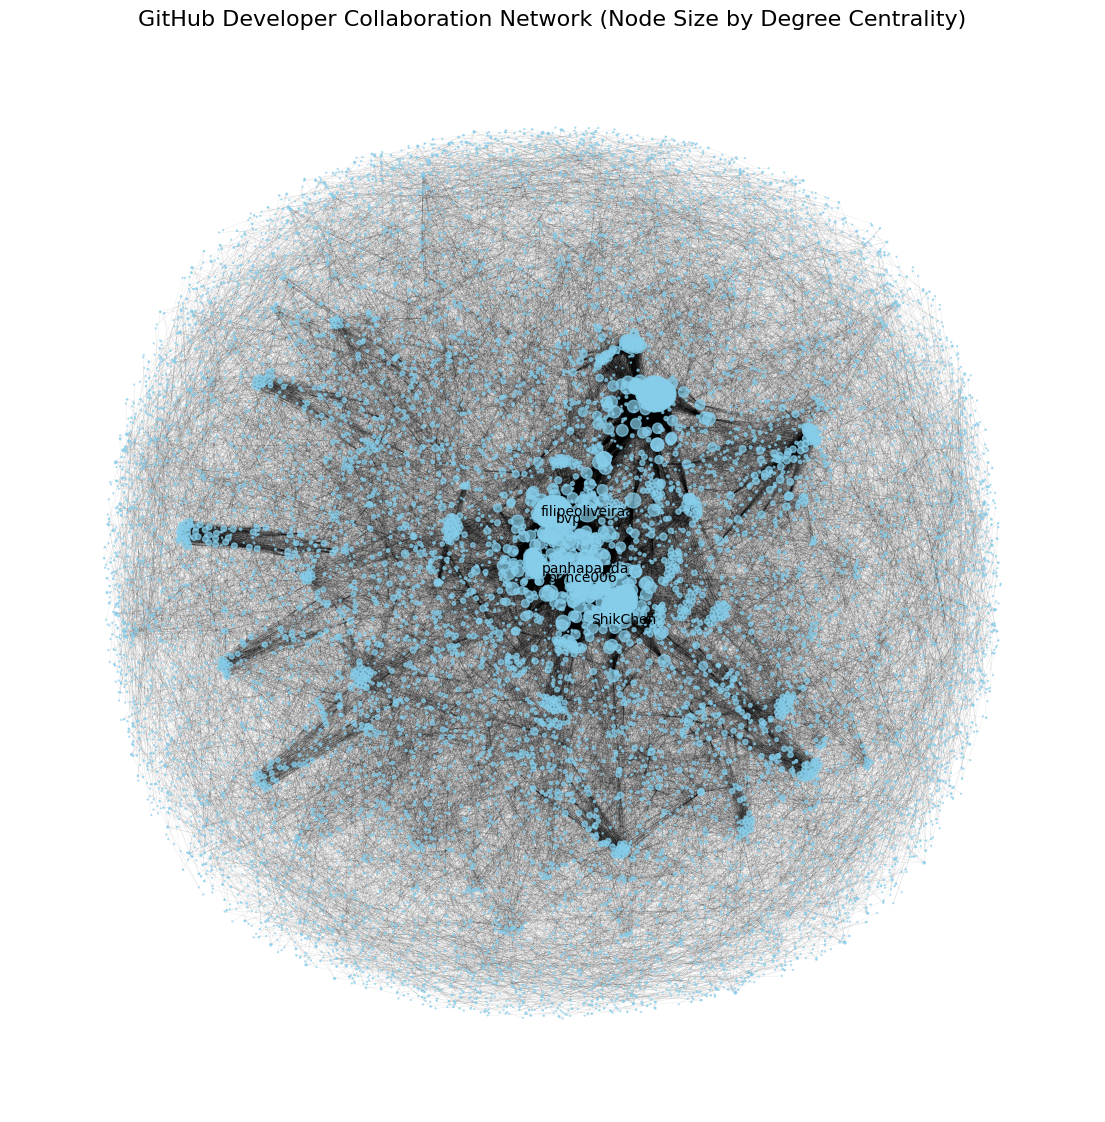

In [ ]:
import matplotlib.pyplot as plt

# Compute Degree Centrality (to set node sizes)
degree_centrality = nx.degree_centrality(G)

top_5 = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("\nTop 5 developers by degree centrality:")
for user, centrality in top_5:
    print(f"Developer: {user}, Degree Centrality: {centrality:.4f}")

# Normalize node sizes (scale centrality scores)
node_sizes = [5000 * degree_centrality[node] for node in G.nodes()]

# Create plot
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# Draw nodes with sizes based on centrality
nx.draw_networkx_nodes(
    G, pos, 
    node_size=[v * 5000 for v in degree_centrality.values()], 
    node_color='skyblue', 
    alpha=0.7
)

# Draw edges with transparency based on weight
edges = G.edges(data=True)
nx.draw_networkx_edges(
    G, pos,
    alpha=0.3, 
    width=[d['weight'] * 0.1 for (_, _, d) in G.edges(data=True)]
)

# Optionally, label only the top 5 central nodes for clarity
top_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]
nx.draw_networkx_labels(G, pos, labels={node: node for node in top_nodes}, font_size=10)

plt.title("GitHub Developer Collaboration Network (Node Size by Degree Centrality)", fontsize=16)
plt.axis('off')
plt.show()


In [41]:
import matplotlib.pyplot as plt
import networkx as nx
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.cm as cm

# Compute communities using modularity-based clustering
communities = list(greedy_modularity_communities(G))
print(f"Detected {len(communities)} communities.")

# Assign colors to communities
color_map = cm.get_cmap('tab20', len(communities))
node_colors = {}
for i, community in enumerate(communities):
    for node in community:
        node_color = cm.tab20(i % 20)  # cycle colors if many communities
        node = node = node = node = node = node = node = node = node = node = node = node = node = node
        node = node = node = node = node = node = node = node = node = node = node = node = node
        node = node
        node = node
        node_colors = {node: node for node in communities[i] for node in community for node in communities[i]}
for i, community in enumerate(communities):
    for node in community:
        G.nodes[node]['color'] = i

# Assign node sizes based on degree centrality
degree_centrality = nx.degree_centrality(G)
node_sizes = [5000 * degree_centrality[node] for node in G.nodes()]

# Visualization setup
plt.figure(figsize=(14, 14))
pos = nx.spring_layout(G, k=0.15, iterations=50, seed=42)

# Draw nodes
for i, community in enumerate(communities):
    nx.draw_networkx_nodes(
        G, pos,
        nodelist=community,
        node_size=[node_sizes[list(G.nodes()).index(node)] for node in community],
        node_color=[color_map(i)],
        alpha=0.8,
        label=f'Community {i+1}'
    )

# Draw edges with transparency
nx.draw_networkx_edges(
    G, pos,
    alpha=0.2,
    width=[d['weight'] * 0.1 for (_, _, d) in G.edges(data=True)]
)

# Label top central nodes clearly
top_nodes = sorted(degree_centrality, key=degree_centrality.get, reverse=True)[:5]
nx.draw_networkx_labels(
    G, pos,
    labels={node: node for node in top_nodes},
    font_size=10,
    font_weight='bold'
)

plt.title("GitHub Developer Collaboration Network with Community Clusters", fontsize=16)
plt.axis('off')
plt.legend()
plt.show()


Detected 2809 communities.


C:\Users\danyi\AppData\Local\Temp\ipykernel_13240\1935586130.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = cm.get_cmap('tab20', len(communities))


KeyboardInterrupt: 

In [39]:
degree_betweenness = nx.betweenness_centrality(G)
top_5 = sorted(degree_betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 developers by betweenness centrality:")
for user, centrality in top_5:
    print(f"Developer: {user}, Betweenness Centrality: {centrality:.4f}")


KeyboardInterrupt: 

In [ ]:
degree_eigenvector = nx.eigenvector_centrality(G)
top_5 = sorted(degree_eigenvector.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 developers by eigenvector centrality:")
for user, centrality in top_5:
    print(f"Developer: {user}, Eigenvector Centrality: {centrality:.4f}")
